# Patch spread profiles

Graphs follow the old `new_experiments/PatchSpread` semantics: raw mean abs delta profiles for JPEG zig-zag, center square spiral, and centered square rings, plus normalized cumulative JPEG spread. Uses full unbalanced cache unless `MAX_EXAMPLES` is set.


In [1]:
from pathlib import Path
import sys

LAB_ROOT = Path.cwd()
if (LAB_ROOT / "classifier_patch_analysis").exists():
    REPO_ROOT = LAB_ROOT.parent
else:
    REPO_ROOT = LAB_ROOT
    LAB_ROOT = REPO_ROOT / "classifier_experiments"
sys.path.insert(0, str(LAB_ROOT))

In [2]:
from classifier_patch_analysis import ClassifierAttackConfig, ClassifierPatchExperiment, ExperimentConfig

SEED = 17
IMG_SIZE = 224
MODEL_CHECKPOINT = str(REPO_ROOT / "data" / "yolo11-cls-person.pt")
BASE_WEIGHTS = str(REPO_ROOT / "data" / "yolo11s-cls.pt")
PATCH_PATH = str(REPO_ROOT / "data" / "cls_patch.png")
DATASET_PATH = str(REPO_ROOT / "datasets" / "COCO_people_224")
DEVICE = "auto"
BATCH_SIZE = 64
SUCCESS_DROP_THRESHOLD = 0.5
TARGET_LAYER = "model.9"

attack_config = ClassifierAttackConfig(
    dataset_path=DATASET_PATH,
    patch_path=PATCH_PATH,
    checkpoint_path=MODEL_CHECKPOINT,
    base_weights_path=BASE_WEIGHTS,
    output_dir=str(LAB_ROOT / "outputs" / "classifier_patch_analysis"),
    img_size=IMG_SIZE,
    device=DEVICE,
    success_drop_threshold=SUCCESS_DROP_THRESHOLD,
    inference_batch_size=BATCH_SIZE,
    seed=SEED,
)
exp = ClassifierPatchExperiment(ExperimentConfig(attack=attack_config, target_layer=TARGET_LAYER))
exp.output_dir, exp.figures_dir

(PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/classifier_experiments/outputs/classifier_patch_analysis'),
 PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/classifier_experiments/outputs/classifier_patch_analysis/figures'))

In [3]:
from classifier_patch_analysis import compute_or_load_patch_spread_profiles

MAX_EXAMPLES = None
# Dataset-level profiles follow the old notebook: target layer only.
# Use exp.all_display_layer_names() only for a deliberate full-layer sweep.
LAYERS = [TARGET_LAYER]
FORCE = False
BUILD_MISSING_LAYER_MAPS = True

cache = exp.build_or_load_cache()
profiles = compute_or_load_patch_spread_profiles(exp, layers=LAYERS, max_examples=MAX_EXAMPLES, n_points=128, build_missing_layer_maps=BUILD_MISSING_LAYER_MAPS, force=FORCE)
summary = profiles["summary_df"]
display(summary.head())
summary.to_csv(exp.output_dir / "patch_spread_profile_summary.csv", index=False)

,index,layer,success,profile,step,x,mean,std,var,count
0,0,model.9,False,center_spiral,0,1.0,0.043486,0.028040,0.000786,1559
1,1,model.9,False,center_spiral,1,2.0,0.053400,0.030540,0.000933,1559
2,2,model.9,False,center_spiral,2,3.0,0.046749,0.028507,0.000813,1559
3,3,model.9,False,center_spiral,3,4.0,0.042325,0.029379,0.000863,1559
4,4,model.9,False,center_spiral,4,5.0,0.040817,0.026277,0.000690,1559


### Plot imports

In [4]:
import matplotlib.pyplot as plt
from classifier_patch_analysis.plots import (
    plot_all_layer_delta_maps_single_example,
    plot_all_layer_zigzag_single_example,
    plot_channel_filtered_delta_examples,
    plot_profile_summary,
    plot_zigzag_cumulative_summary,
    savefig,
)

### All layers: one successful attack

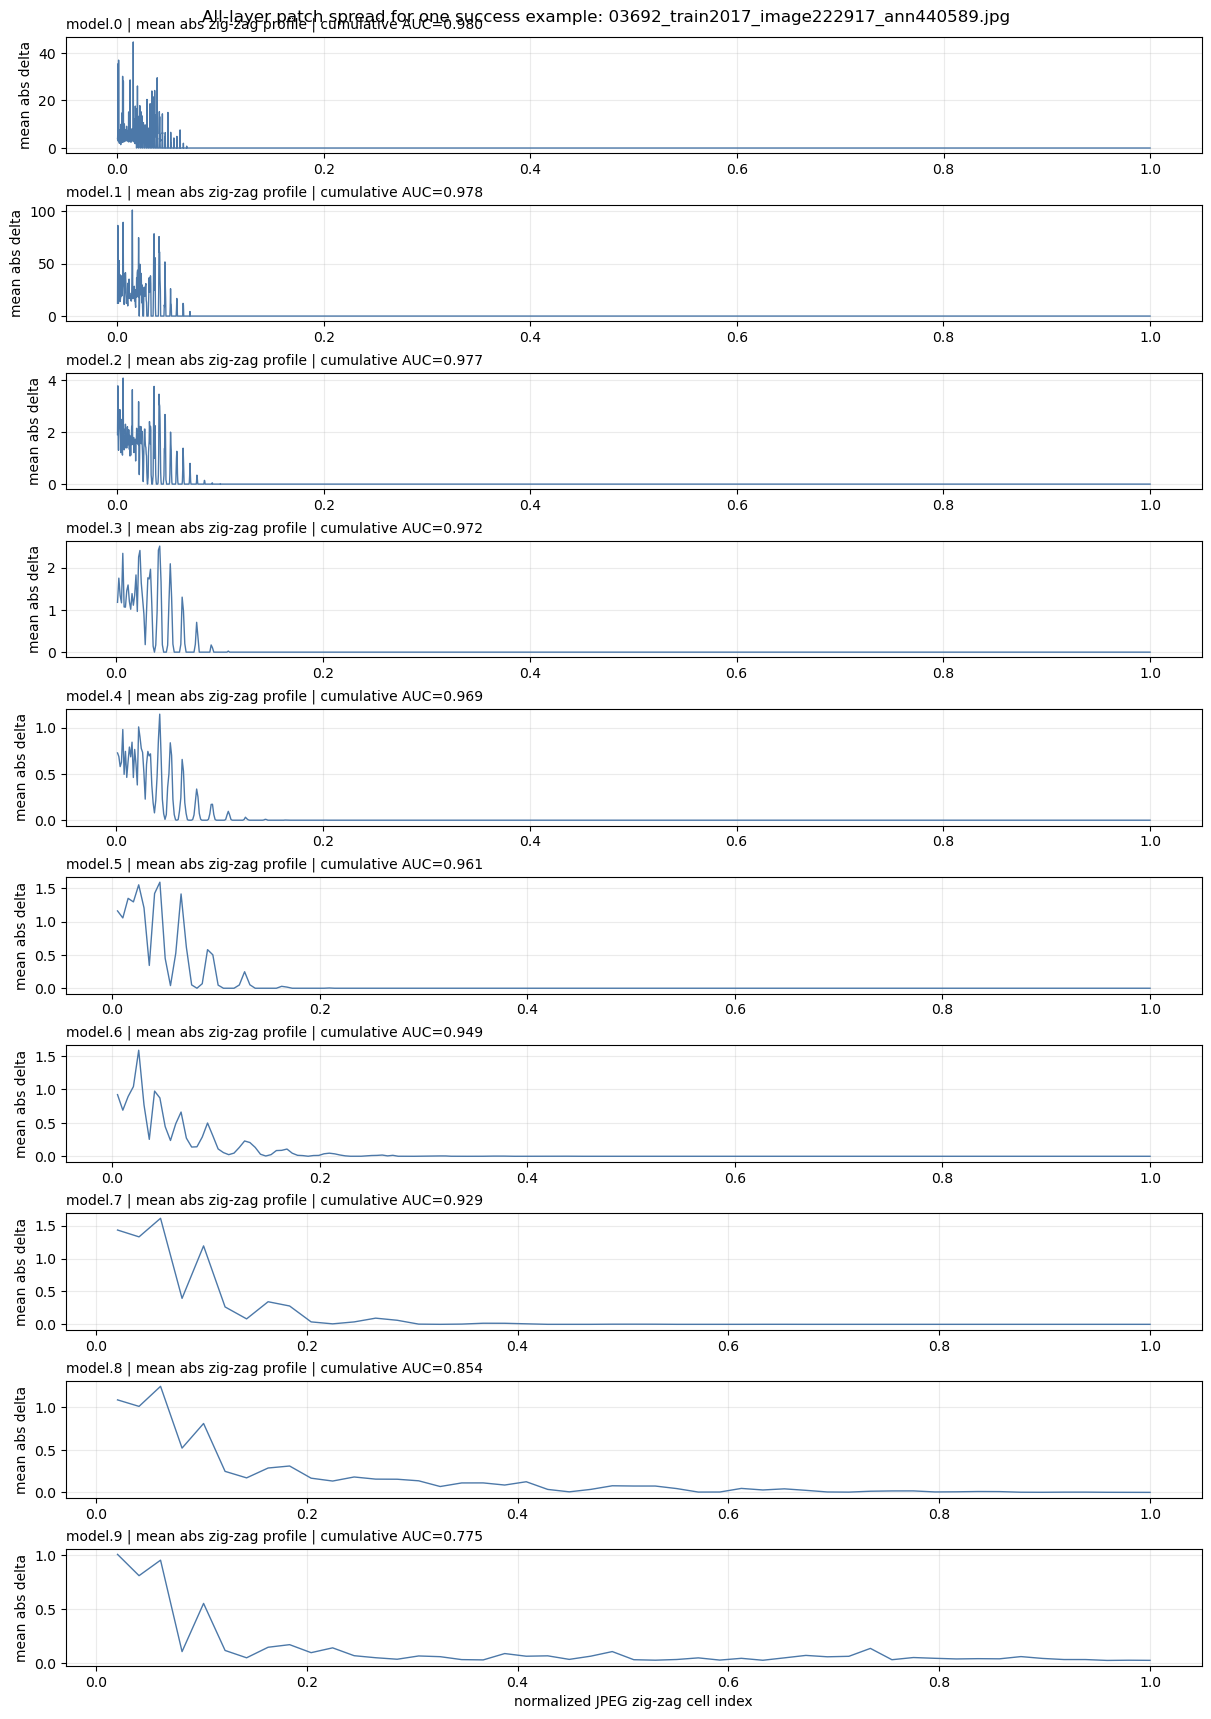

In [5]:
success_layer_example = sorted(cache.successes, key=lambda item: item.drop, reverse=True)[0] if cache.successes else cache.examples[0]
fig = plot_all_layer_zigzag_single_example(
    exp,
    success_layer_example,
    layers=exp.all_display_layer_names(),
    build_missing=True,
)
savefig(fig, exp.figures_dir / "patch_spread_all_layers_one_success_zigzag.png")
display(fig)
plt.close(fig)

### All layers: one failed attack

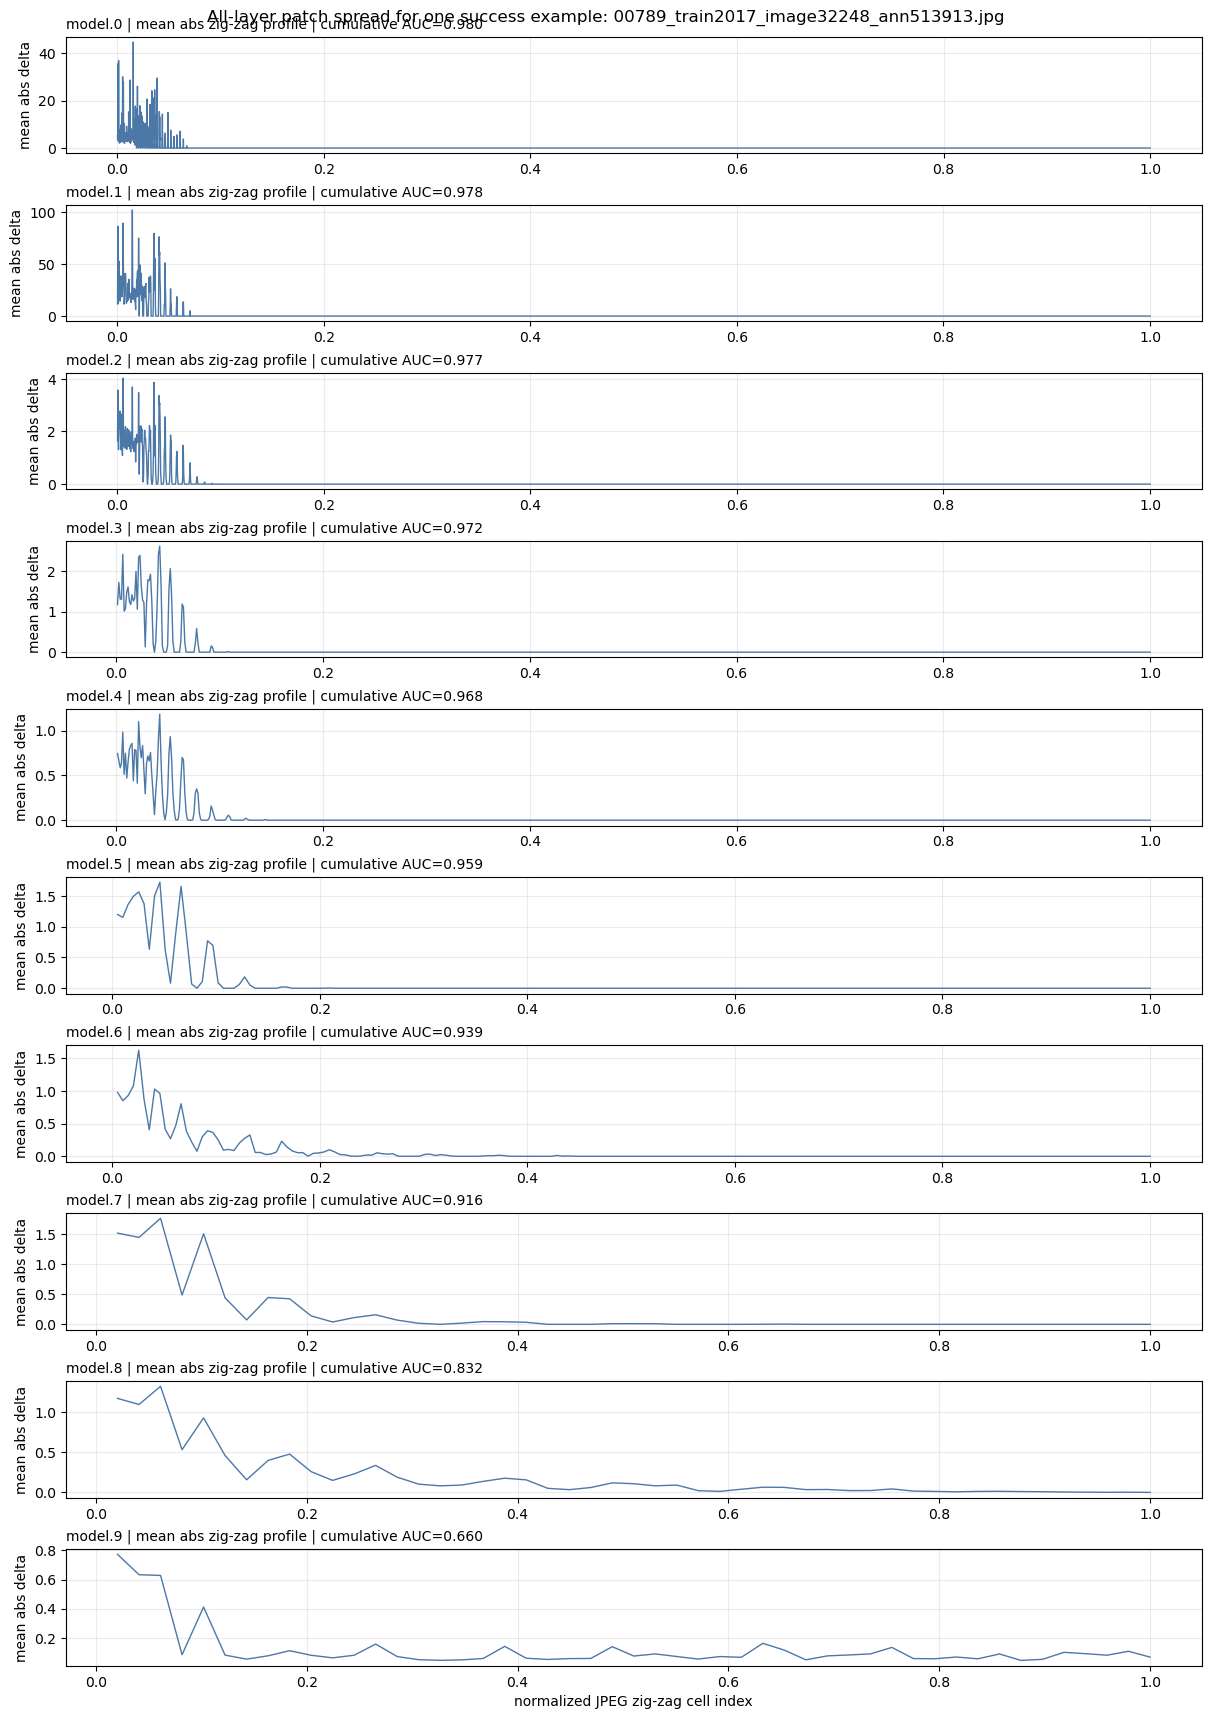

In [6]:
fail_layer_example = sorted(cache.failures, key=lambda item: item.drop)[0] if cache.failures else cache.examples[-1]
fig = plot_all_layer_zigzag_single_example(
    exp,
    fail_layer_example,
    layers=exp.all_display_layer_names(),
    build_missing=True,
)
savefig(fig, exp.figures_dir / "patch_spread_all_layers_one_fail_zigzag.png")
display(fig)
plt.close(fig)

### All-layer delta maps: one successful attack

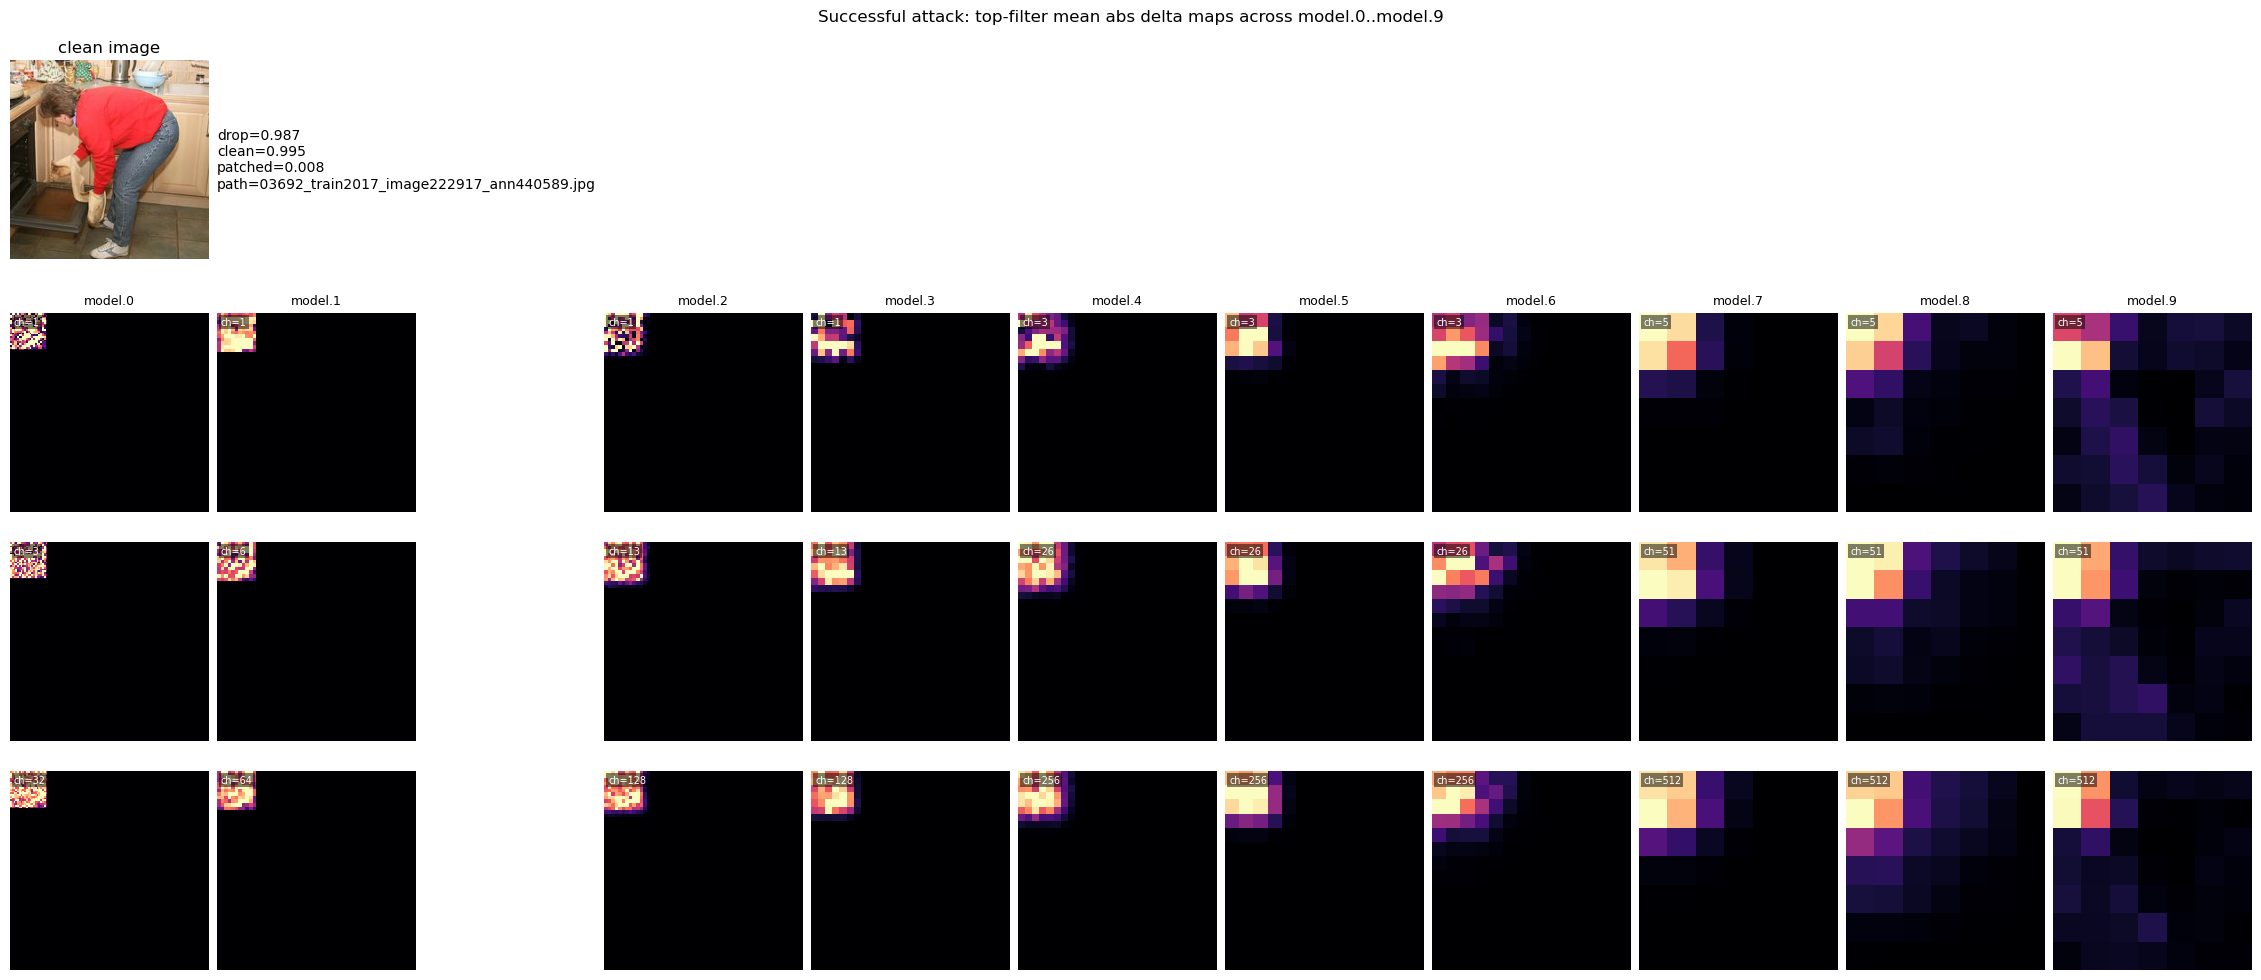

In [7]:
fig = plot_all_layer_delta_maps_single_example(
    exp,
    success_layer_example,
    layers=exp.all_display_layer_names(),
    build_missing=True,
    title="Successful attack: top-filter mean abs delta maps across model.0..model.9",
)
savefig(fig, exp.figures_dir / "patch_spread_all_layers_one_success_delta_maps.png")
display(fig)
plt.close(fig)

### All-layer delta maps: one failed attack

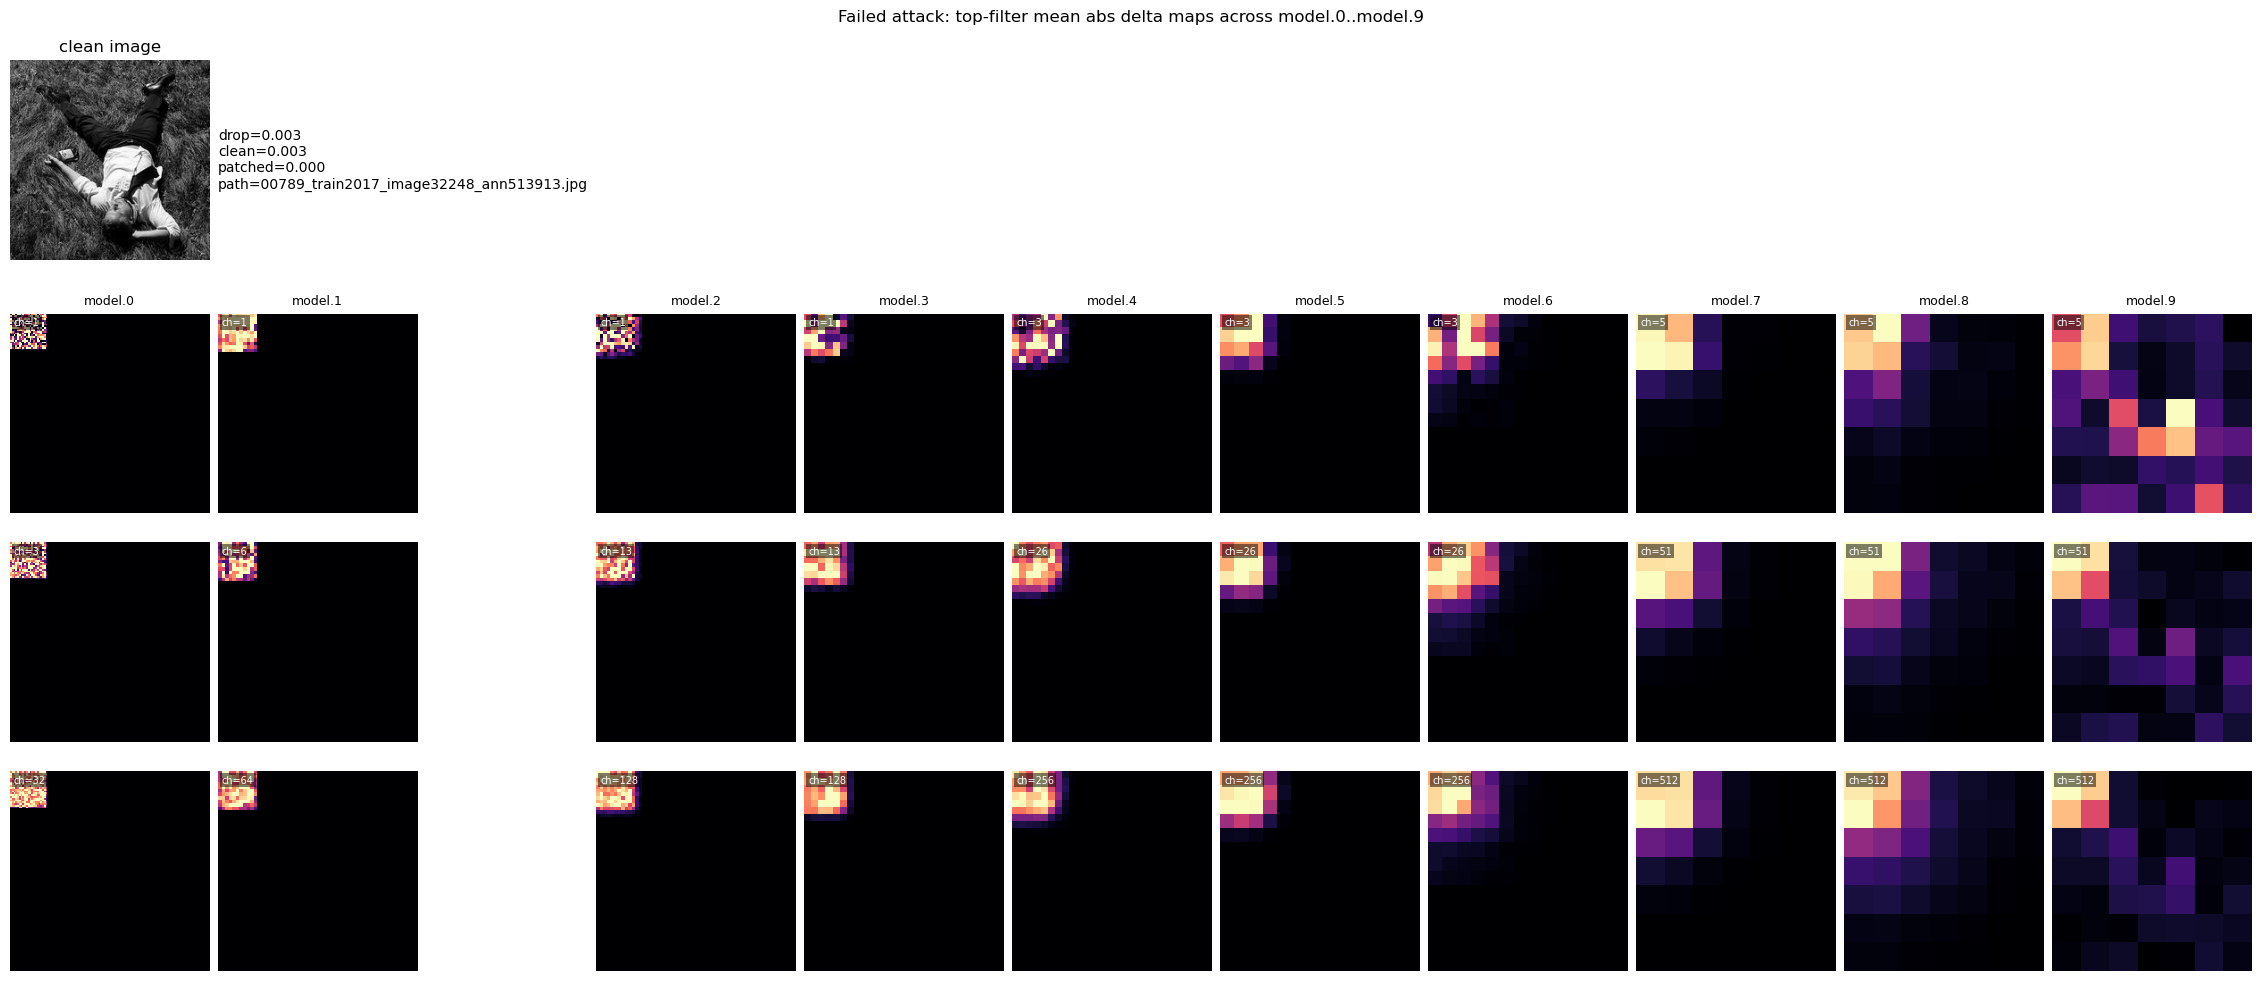

In [8]:
fig = plot_all_layer_delta_maps_single_example(
    exp,
    fail_layer_example,
    layers=exp.all_display_layer_names(),
    build_missing=True,
    title="Failed attack: top-filter mean abs delta maps across model.0..model.9",
)
savefig(fig, exp.figures_dir / "patch_spread_all_layers_one_fail_delta_maps.png")
display(fig)
plt.close(fig)

### Target-layer spread profiles

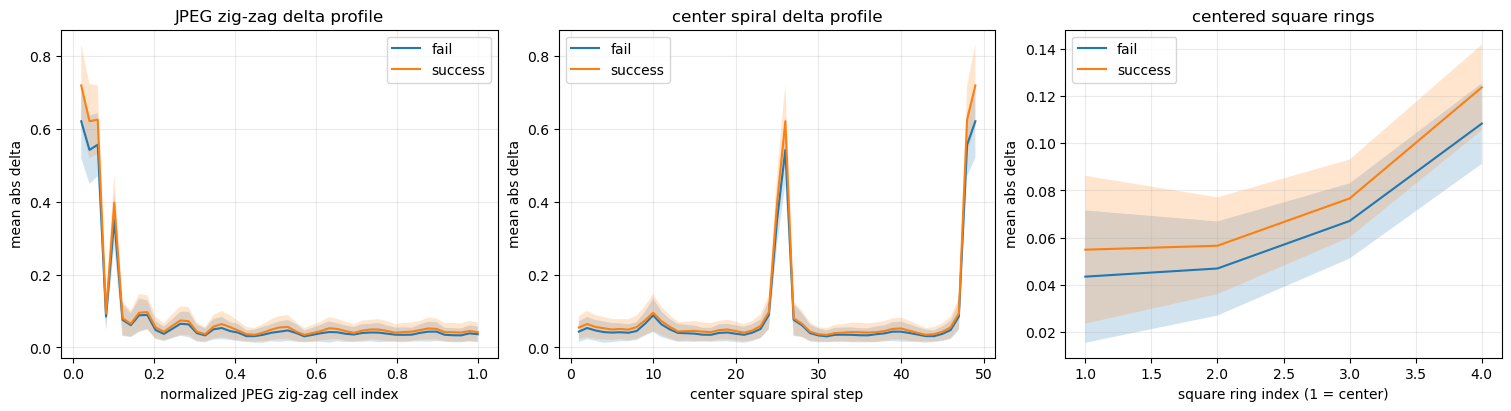

In [9]:
fig = plot_profile_summary(summary, layer=TARGET_LAYER)
savefig(fig, exp.figures_dir / f"patch_spread_profiles_{TARGET_LAYER.replace('.', '_')}_target.png")
display(fig)
plt.close(fig)

### JPEG zig-zag cumulative spread

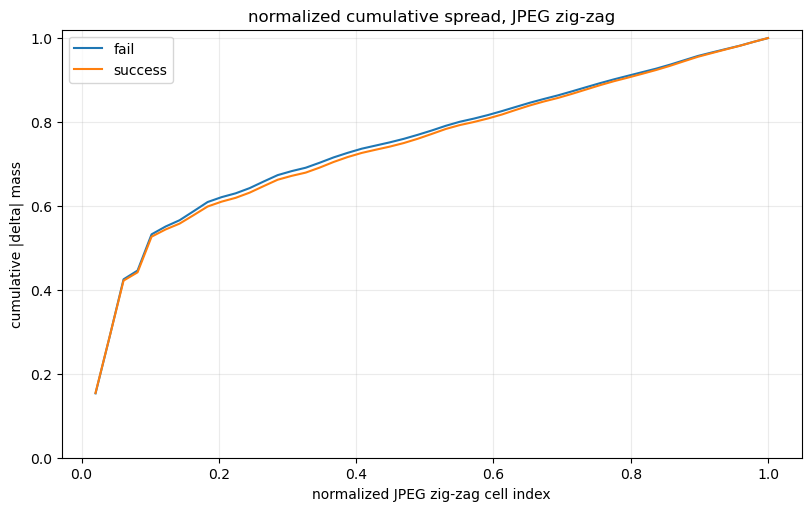

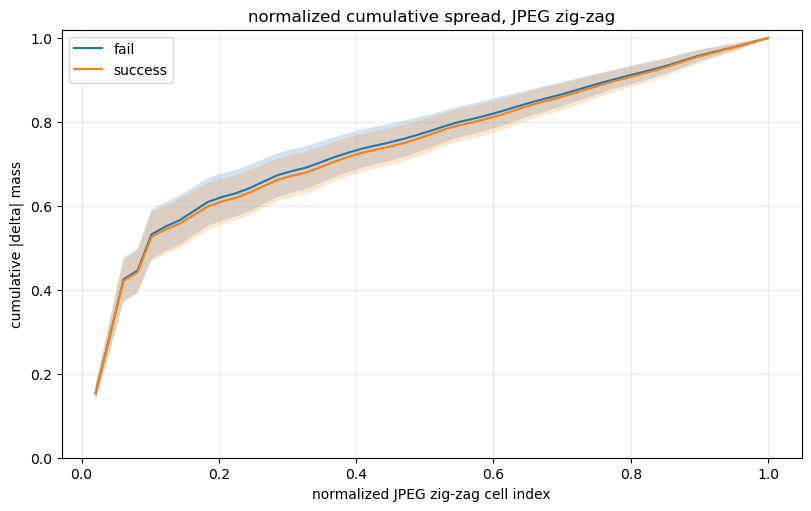

In [10]:
fig = plot_zigzag_cumulative_summary(profiles["profiles_df"], layer=TARGET_LAYER, with_std=False)
savefig(fig, exp.figures_dir / f"patch_spread_zigzag_cumulative_{TARGET_LAYER.replace('.', '_')}.png")
display(fig)
plt.close(fig)

fig = plot_zigzag_cumulative_summary(profiles["profiles_df"], layer=TARGET_LAYER, with_std=True)
savefig(fig, exp.figures_dir / f"patch_spread_zigzag_cumulative_std_{TARGET_LAYER.replace('.', '_')}.png")
display(fig)
plt.close(fig)

### Top-filter delta maps: successful attacks

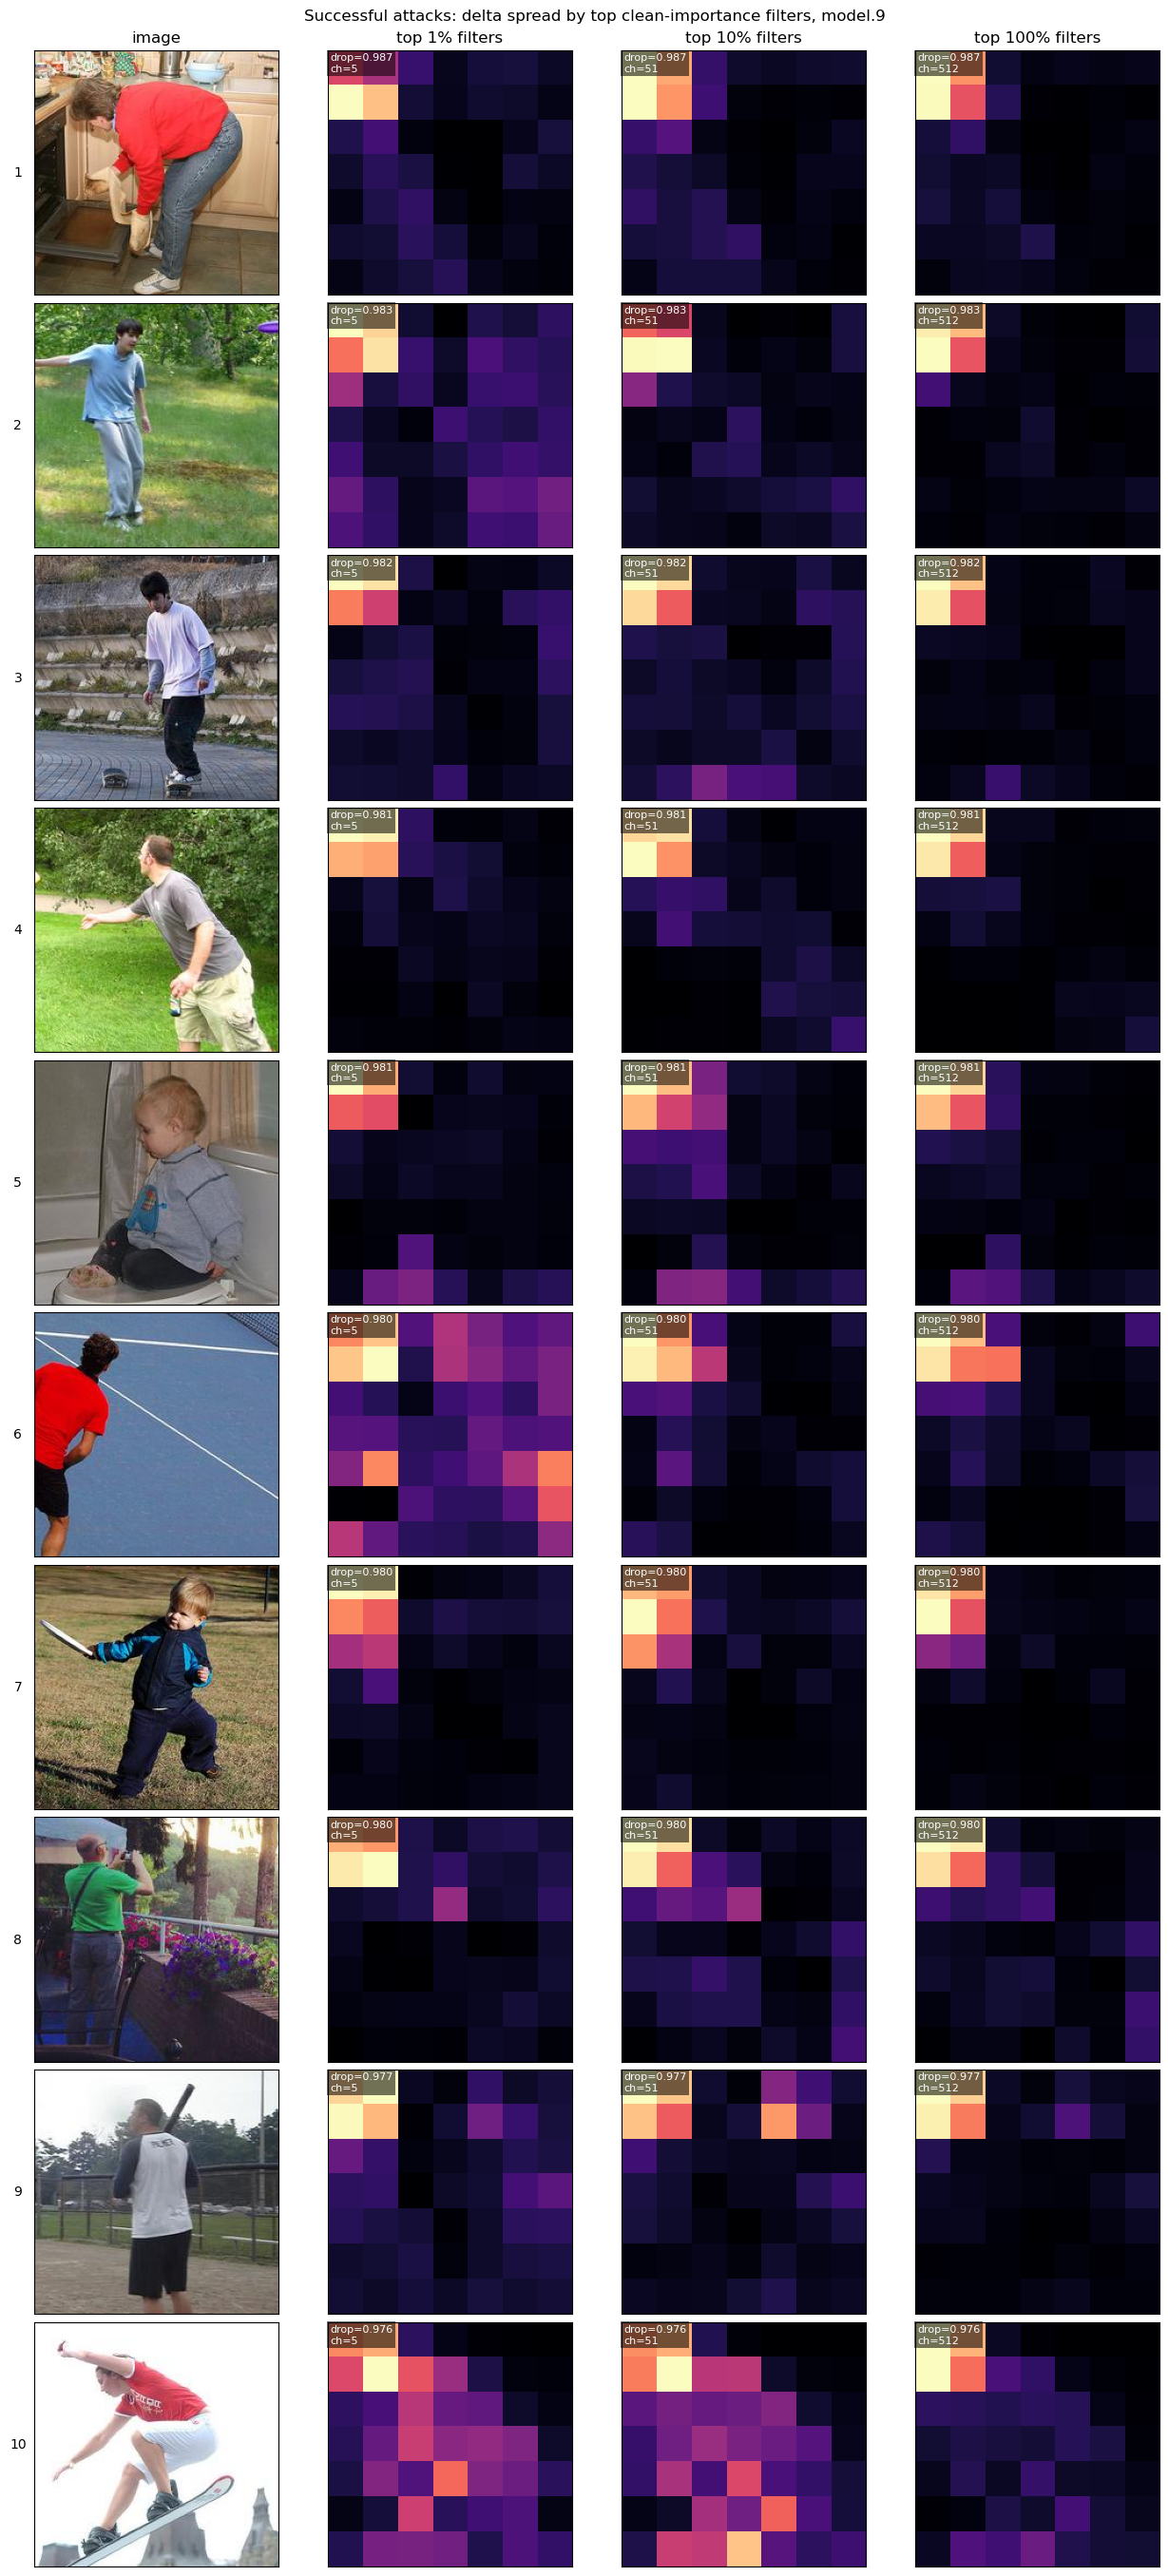

In [11]:
success_for_maps = sorted(cache.successes, key=lambda item: item.drop, reverse=True)[:10]
fig = plot_channel_filtered_delta_examples(
    exp,
    success_for_maps,
    layer_name=TARGET_LAYER,
    fractions=(1, 10, 100),
    max_examples=10,
    title=f"Successful attacks: delta spread by top clean-importance filters, {TARGET_LAYER}",
)
savefig(fig, exp.figures_dir / f"patch_spread_success_top_filter_delta_{TARGET_LAYER.replace('.', '_')}.png")
display(fig)
plt.close(fig)

### Top-filter delta maps: failed attacks

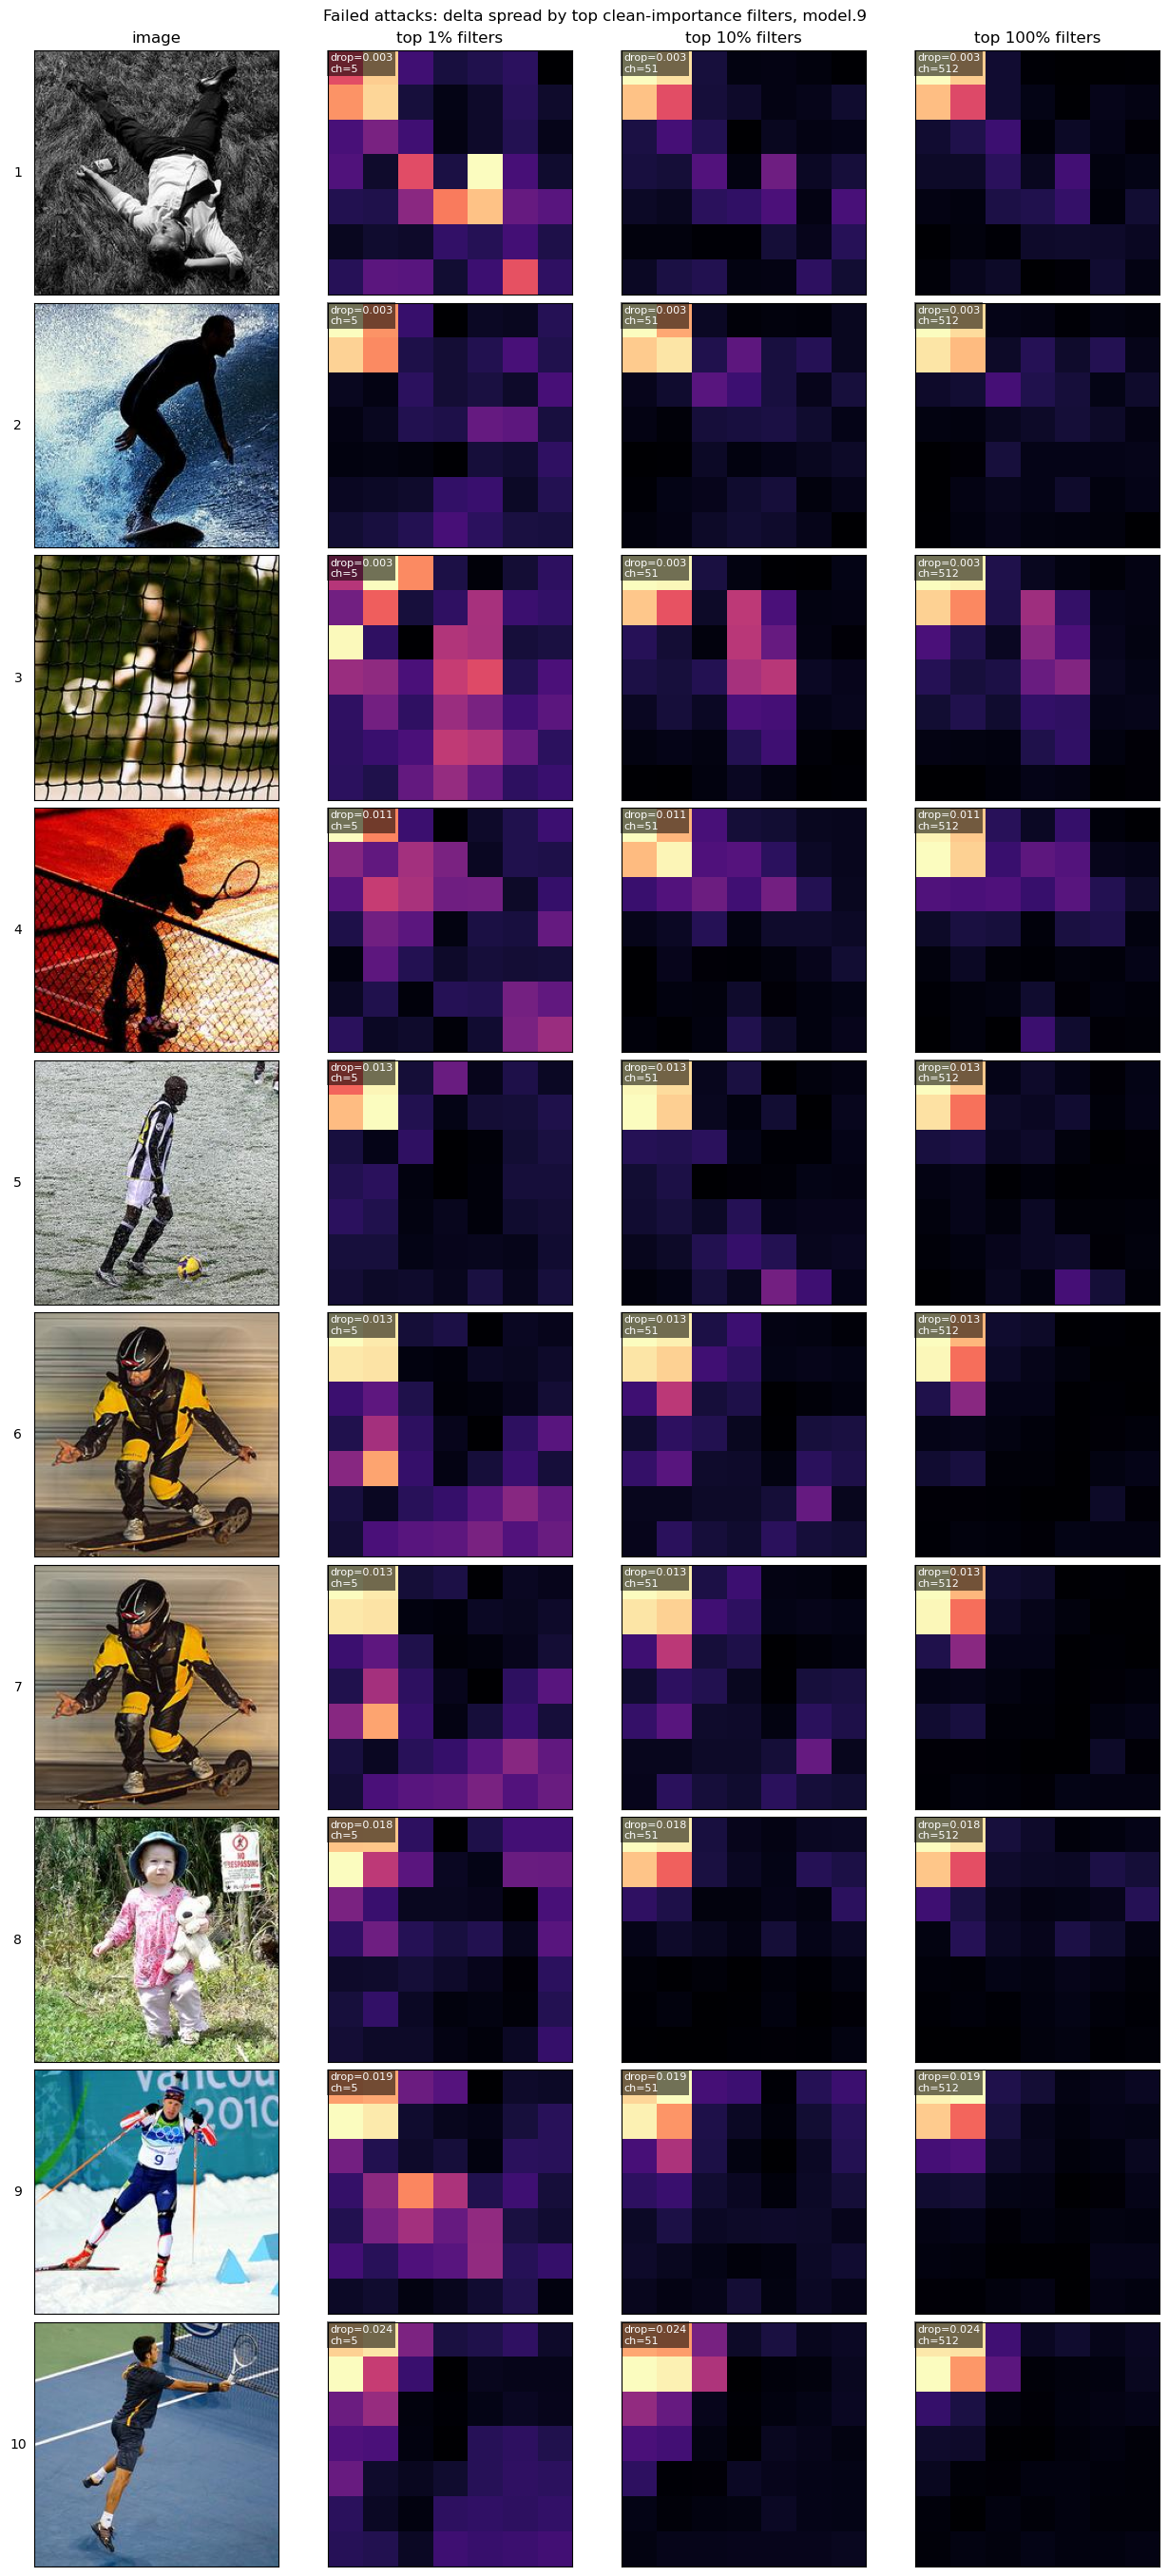

: 

In [ ]:
fail_for_maps = sorted(cache.failures, key=lambda item: item.drop)[:10]
fig = plot_channel_filtered_delta_examples(
    exp,
    fail_for_maps,
    layer_name=TARGET_LAYER,
    fractions=(1, 10, 100),
    max_examples=10,
    title=f"Failed attacks: delta spread by top clean-importance filters, {TARGET_LAYER}",
)
savefig(fig, exp.figures_dir / f"patch_spread_fail_top_filter_delta_{TARGET_LAYER.replace('.', '_')}.png")
display(fig)
plt.close(fig)